In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
from data import load_full_dataset
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
data = load_full_dataset()

In [3]:
# Prepare the data

target_cols = ["Pastry", "Z_Scratch", "K_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

# Merge steel type
data["steel_type"] = data.apply(
    lambda r: 0 if r["TypeOfSteel_A300"] == 1 else 1, axis=1
)

# Drop redundant features (same list as cleaning)
redundant = [
    "X_Maximum", "Y_Maximum",
    "X_Perimeter", "Y_Perimeter",
    "Sum_of_Luminosity", "SigmoidOfAreas",
    "Log_X_Index", "Log_Y_Index",
    "Maximum_of_Luminosity", "Minimum_of_Luminosity",
    "Outside_Global_Index",
    "TypeOfSteel_A300", "TypeOfSteel_A400",
] + target_cols

to_drop = [c for c in redundant if c in data.columns]
data = data.drop(columns=to_drop)

# Target is Pixels_Areas
target = "Pixels_Areas"
feature_cols = [c for c in data.columns if c != target]

X = data[feature_cols]
y = data[target]

print(f"Features: {feature_cols}")
print(f"Target range: {y.min()} to {y.max()}")
print(f"Target mean:  {y.mean():.1f}")

Features: ['X_Minimum', 'Y_Minimum', 'Length_of_Conveyer', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'LogOfAreas', 'Orientation_Index', 'Luminosity_Index', 'steel_type']
Target range: 2 to 152655
Target mean:  1893.9


In [5]:
# Split and scale

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

Train: (1552, 14) | Test: (389, 14)


In [6]:
# Train the regressor

reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

reg.fit(X_train_scaled, y_train)
joblib.dump(reg, "../outputs/models/sizing_regressor.pkl")
print("Model saved.")


Model saved.


In [8]:
# Evaluate
preds = reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds)
r2  = r2_score(y_test, preds)

print(f"MAE:  {mae:.2f} pixels")
print(f"R²:   {r2:.4f}")

MAE:  7.18 pixels
R²:   0.9999


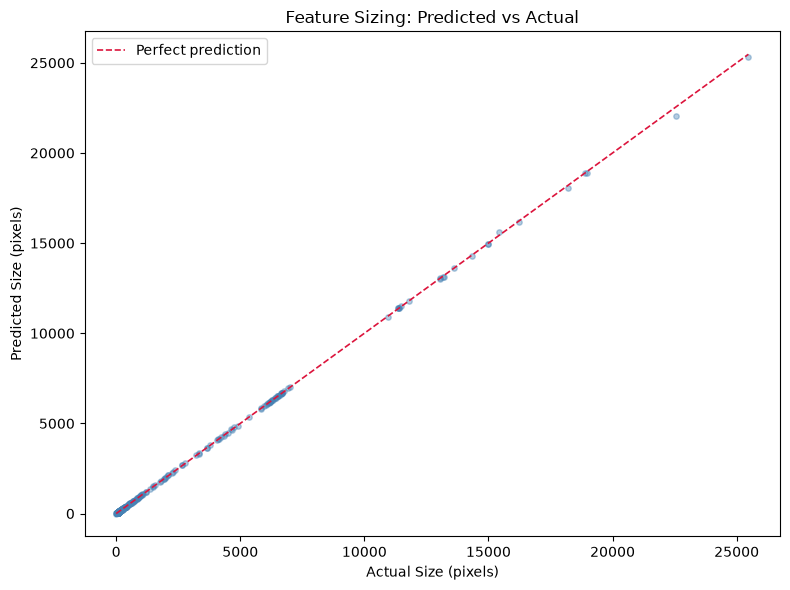

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.4, color="steelblue", s=15)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="crimson", linewidth=1.2, linestyle="--", label="Perfect prediction"
)
plt.xlabel("Actual Size (pixels)")
plt.ylabel("Predicted Size (pixels)")
plt.title("Feature Sizing: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/sizing_scatter.png", dpi=150)
plt.show()

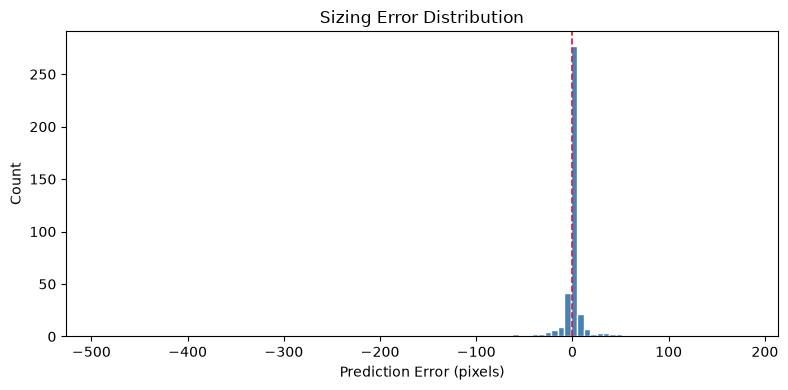

Mean error:   -1.80
Std of error: 30.68


In [11]:
errors = preds - y_test.values

plt.figure(figsize=(8, 4))
plt.hist(errors, bins=100, color="steelblue", edgecolor="white")
plt.axvline(0, color="crimson", linestyle="--", linewidth=1.2)
plt.xlabel("Prediction Error (pixels)")
plt.ylabel("Count")
plt.title("Sizing Error Distribution")
plt.tight_layout()
plt.savefig("../outputs/figures/sizing_error_distribution.png", dpi=150)
plt.show()

print(f"Mean error:   {errors.mean():.2f}")
print(f"Std of error: {errors.std():.2f}")

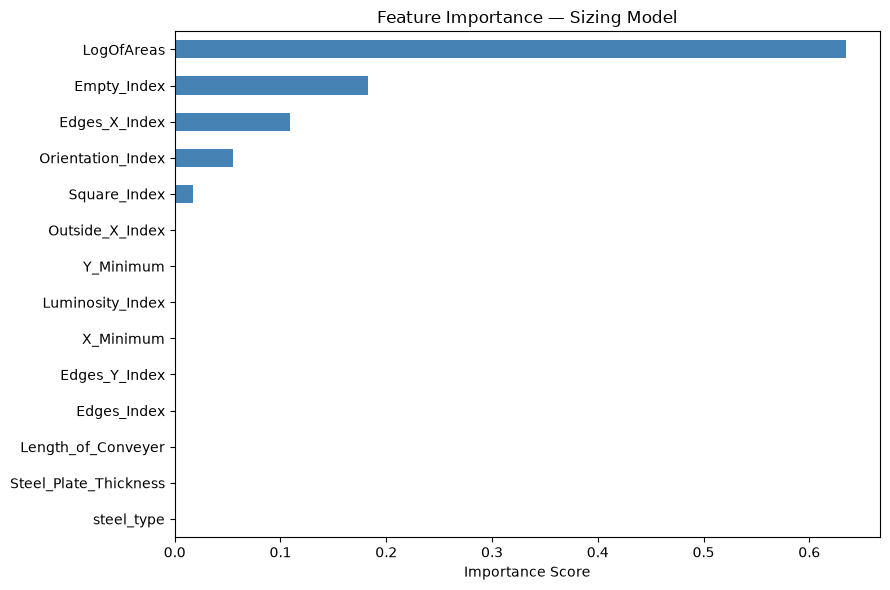

In [12]:
# Feature importance for sizing

importances = pd.Series(reg.feature_importances_, index=feature_cols)
importances.sort_values(ascending=True).plot(
    kind="barh",
    figsize=(9, 6),
    title="Feature Importance — Sizing Model",
    color="steelblue"
)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../outputs/figures/sizing_feature_importance.png", dpi=150)
plt.show()


The regression model predicts defect pixel area from geometric and luminosity features. A high R² is expected here: several retained features such as LogOfAreas and Orientation_Index are mathematically derived from area itself, so the model is partly recovering a known relationship rather than discovering something new.


In a real in-line inspection context, the sizing target would be defect depth as a percentage of wall thickness, or axial length in millimetres. Those are harder predictions because they require inverting a physical signal (MFL flux leakage or
ultrasonic time-of-flight) rather than predicting a geometric summary. The approach here demonstrates the regression framework and the sizing workflow; the target would change but the methodology would not.

The error distribution and scatter plot show where the model sizes accurately and where it struggles. Large defects at the upper end of the size range tend to have wider prediction errors, which is typical: rare extreme values have less training data and the model regresses toward the mean.